In [34]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
import logging, os, random, subprocess, tempfile, unittest, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin

warnings.filterwarnings("ignore")

# Setup logging to print standard output in Colab
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s  %(levelname)-8s  %(message)s",
                    datefmt="%H:%M:%S",
                    force=True) # Force reconfiguration in notebook environments
log = logging.getLogger(__name__)

plt.rcParams["font.size"] = 14

# Scoring constants
TIER1_THRESHOLD = 0.7
TIER2_THRESHOLD = 0.5

COMPOSITE_WEIGHTS = {
    "druggability_proba":  0.40,
    "conservation_score":  0.25,
    "has_structure_bonus": 0.15,
    "length_druggability": 0.10,
    "has_function_bonus":  0.10,
}

MC_N_SAMPLES   = 1_000
MC_DIRICHLET_A = 10.0

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

In [35]:
# ── 1-3. Data Collection, Processing & Cleaning ──────────────────────────────
def fetch_listeria_proteome():
    params = {
        "query":  "organism_id:169963 AND reviewed:true",
        "format": "json",
        "size":   500,
        "fields": (
            "accession,id,gene_names,protein_name,length,sequence,"
            "cc_function,cc_subcellular_location,xref_pdb,xref_drugbank"
        ),
    }
    log.info("Fetching L. monocytogenes proteome from UniProt...")
    r = requests.get("https://rest.uniprot.org/uniprotkb/search", params=params, timeout=60)
    r.raise_for_status()
    results = r.json().get("results", [])
    if not results:
        raise RuntimeError("UniProt returned 0 results. Check query or connectivity.")
    log.info("Retrieved %d entries.", len(results))
    return results

def process_uniprot_data(raw_entries):
    records, skipped = [], 0
    for e in raw_entries:
        accession = e.get("primaryAccession", "").strip()
        sequence  = e.get("sequence", {}).get("value", "").strip()

        if not accession or not sequence:
            skipped += 1
            continue

        rec = {
            "accession":            accession,
            "entry_name":           e.get("uniProtkbId", ""),
            "protein_name":         "",
            "gene_name":            "",
            "length":               e.get("sequence", {}).get("length", 0),
            "sequence":             sequence,
            "function":             "",
            "subcellular_location": "",
            "pdb_structures":       "",
            "drugbank_targets":     "",
        }
        desc = e.get("proteinDescription", {})
        if "recommendedName" in desc:
            rec["protein_name"] = desc["recommendedName"].get("fullName", {}).get("value", "")
        genes = e.get("genes", [])
        if genes:
            rec["gene_name"] = genes[0].get("geneName", {}).get("value", "")

        for c in e.get("comments", []):
            ct = c.get("commentType", "")
            if ct == "FUNCTION":
                texts = c.get("texts", [])
                if texts: rec["function"] = texts[0].get("value", "")
            elif ct == "SUBCELLULAR LOCATION":
                locs = c.get("subcellularLocations", [])
                if locs: rec["subcellular_location"] = locs[0].get("location", {}).get("value", "")
        
        pdb, db = [], []
        for x in e.get("uniProtKBCrossReferences", []):
            if x.get("database") == "PDB": pdb.append(x.get("id", ""))
            elif x.get("database") == "DrugBank": db.append(x.get("id", ""))
        rec["pdb_structures"]   = "; ".join(pdb)
        rec["drugbank_targets"] = "; ".join(db)
        records.append(rec)

    if skipped: log.warning("Skipped %d entries missing accession or sequence.", skipped)
    df = pd.DataFrame(records)
    log.info("Processed %d proteins.", len(df))
    return df

def clean_data(df):
    df = df[df["sequence"].notna() & (df["sequence"] != "")].copy()
    df = df[(df["length"] >= 50) & (df["length"] <= 2000)].copy()
    for col in ["function", "subcellular_location", "gene_name", "protein_name"]:
        df[col] = df[col].fillna("")
    log.info("After cleaning: %d proteins.", len(df))
    return df

def assign_length_druggability(df):
    bins      = [0, 150, 200, 450, 700, float("inf")]
    labels    = ["Very Small", "Small", "Optimal", "Large", "Very Large"]
    score_map = {"Very Small": 0.3, "Small": 0.6, "Optimal": 1.0, "Large": 0.8, "Very Large": 0.4}
    df = df.copy()
    df["length_category"]     = pd.cut(df["length"], bins=bins, labels=labels)
    df["length_druggability"] = df["length_category"].map(score_map)
    return df

In [36]:
# ── 4-5. Feature Flags & EDA ─────────────────────────────────────────────────
def add_feature_flags(df):
    flag_defs = {
        "has_function":   ("function",             lambda s: s.str.len() > 10),
        "has_structure":  ("pdb_structures",       lambda s: s.str.len() > 0),
        "has_drugbank":   ("drugbank_targets",     lambda s: s.str.len() > 0),
        "has_gene_name":  ("gene_name",            lambda s: s.str.len() > 0),
        "is_membrane":    ("subcellular_location", lambda s: s.str.contains("membrane",  case=False, na=False)),
        "is_cytoplasmic": ("subcellular_location", lambda s: s.str.contains("cytoplasm", case=False, na=False)),
    }
    for flag, (col, fn) in flag_defs.items():
        df[flag] = fn(df[col])
    for col in ["has_function", "has_structure", "has_drugbank", "has_gene_name", "is_membrane", "is_cytoplasmic"]:
        log.info("  %s: %d", col, df[col].sum())
    return df

def run_eda(df):
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))

    axes[0, 0].hist(df["length"], bins=30, alpha=0.7, color="skyblue")
    axes[0, 0].set(xlabel="Length (aa)", ylabel="Count", title="Protein Length Distribution")

    annot = {"Function": df["has_function"].sum(), "Structure": df["has_structure"].sum(),
             "Gene Name": df["has_gene_name"].sum(), "Drug Target": df["has_drugbank"].sum()}
    axes[0, 1].bar(annot.keys(), annot.values(), color="lightgreen")
    axes[0, 1].set(ylabel="Proteins", title="Annotation Coverage")
    axes[0, 1].tick_params(axis="x", rotation=45)

    loc_counts = df["subcellular_location"].value_counts().head(6)
    axes[0, 2].pie(loc_counts.values, labels=loc_counts.index, autopct="%1.1f%%")
    axes[0, 2].set_title("Subcellular Locations")

    axes[1, 0].boxplot([df[df["has_function"]]["length"], df[~df["has_function"]]["length"]],
                       labels=["With Function", "No Function"])
    axes[1, 0].set(ylabel="Length", title="Length vs Function Annotation")

    feat_cols = ["length", "has_function", "has_structure", "is_membrane"]
    corr = df[feat_cols].corr()
    im = axes[1, 1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
    axes[1, 1].set_xticks(range(len(feat_cols)))
    axes[1, 1].set_xticklabels(feat_cols, rotation=45, ha="right")
    axes[1, 1].set_yticks(range(len(feat_cols)))
    axes[1, 1].set_yticklabels(feat_cols)
    axes[1, 1].set_title("Feature Correlations")
    for i in range(len(feat_cols)):
        for j in range(len(feat_cols)):
            axes[1, 1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=12)

    quality = {"Complete": len(df), "Has Sequence": (df["sequence"].str.len() > 0).sum(),
               "Has Function": df["has_function"].sum(), "Has Location": (df["subcellular_location"].str.len() > 0).sum()}
    axes[1, 2].bar(range(len(quality)), list(quality.values()))
    axes[1, 2].set_xticks(range(len(quality)))
    axes[1, 2].set_xticklabels(quality.keys(), rotation=45, ha="right")
    axes[1, 2].set(ylabel="Count", title="Data Completeness")

    plt.tight_layout(pad=3.0)
    plt.show() # Will render inline in Colab

In [37]:
# ── 6-7. Physicochemical Features & Conservation ─────────────────────────────
def calculate_molecular_weight(sequence):
    aa_masses = { "A": 71.04, "R": 156.10, "N": 114.04, "D": 115.03, "C": 103.01, "E": 129.04, "Q": 128.06, "G":  57.02, "H": 137.06, "I": 113.08, "L": 113.08, "K": 128.09, "M": 131.04, "F": 147.07, "P":  97.05, "S":  87.03, "T": 101.05, "W": 186.08, "Y": 163.06, "V":  99.07 }
    mw = sum(aa_masses.get(aa, 111.1) for aa in sequence.upper()) + 18.01
    return round(mw / 1000, 2)

def calculate_pI(sequence):
    pKa = {"D": 3.9, "E": 4.1, "C": 8.3, "Y": 10.1, "H": 6.0, "K": 10.5, "R": 12.5, "N_term": 8.0, "C_term": 3.1}
    seq, counts = sequence.upper(), {aa: sequence.upper().count(aa) for aa in pKa if len(aa) == 1}

    def charge_at_pH(pH):
        q  =  1 / (1 + 10 ** (pH - pKa["N_term"])) - 1 / (1 + 10 ** (pKa["C_term"] - pH))
        for aa in ("H", "K", "R"): q += counts[aa] / (1 + 10 ** (pH - pKa[aa]))
        for aa in ("D", "E", "C", "Y"): q -= counts[aa] / (1 + 10 ** (pKa[aa] - pH))
        return q

    lo, hi = 0.0, 14.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if charge_at_pH(mid) > 0: lo = mid
        else: hi = mid
    return round(mid, 2)

def calculate_hydropathy(sequence):
    kd = {"A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C":  2.5, "E": -3.5, "Q": -3.5, "G": -0.4, "H": -3.2, "I":  4.5, "L":  3.8, "K": -3.9, "M":  1.9, "F":  2.8, "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9, "Y": -1.3, "V":  4.2}
    scores = [kd.get(aa, 0) for aa in sequence.upper()]
    return round(float(np.mean(scores)), 3) if scores else 0.0

def calculate_aromaticity(sequence):
    return round(sum(sequence.upper().count(aa) for aa in "FWY") / len(sequence), 4) if sequence else 0.0

def calculate_instability_index(sequence):
    if len(sequence) < 2: return 0.0
    try: return round(ProteinAnalysis(sequence.upper()).instability_index(), 2)
    except Exception: return 0.0

def add_physicochemical_features(df):
    df = df.copy()
    df["molecular_weight_kDa"] = df["sequence"].apply(calculate_molecular_weight)
    df["pI"]                   = df["sequence"].apply(calculate_pI)
    df["hydropathy_index"]     = df["sequence"].apply(calculate_hydropathy)
    df["aromaticity"]          = df["sequence"].apply(calculate_aromaticity)
    df["instability_index"]    = df["sequence"].apply(calculate_instability_index)
    df["is_stable"]            = df["instability_index"] < 40
    log.info("Physicochemical features added. Stable proteins: %d", df["is_stable"].sum())
    return df

def compute_clustal_conservation(df):
    records = [SeqRecord(Seq(r["sequence"]), id=r["accession"], description=r["gene_name"]) for _, r in df.iterrows() if r["sequence"]]
    log.info("Running ClustalOmega on %d sequences...", len(records))

    with tempfile.NamedTemporaryFile(suffix=".fasta", delete=False, mode="w") as fh:
        SeqIO.write(records, fh, "fasta")
        infile = fh.name
    outfile = infile.replace(".fasta", "_aln.fasta")

    def _fallback(reason):
        log.warning("%s — returning 0.5 for all conservation scores.", reason)
        if os.path.exists(infile):  os.unlink(infile)
        if os.path.exists(outfile): os.unlink(outfile)
        return {acc: 0.5 for acc in df["accession"]}

    try:
        subprocess.run(["clustalo", "-i", infile, "-o", outfile, "--force", "--outfmt=fasta", "--threads=4"], check=True, capture_output=True)
    except FileNotFoundError: return _fallback("clustalo not found on PATH")
    except subprocess.CalledProcessError as e: return _fallback(f"ClustalOmega error: {e.stderr.decode().strip()}")

    if not os.path.exists(outfile) or os.path.getsize(outfile) == 0: return _fallback("ClustalOmega produced no output file")
    try: alignment = AlignIO.read(outfile, "fasta")
    except Exception as e: return _fallback(f"Could not parse alignment: {e}")

    aln_len = alignment.get_alignment_length()
    if aln_len == 0: return _fallback("Alignment has zero length")

    scores = {}
    for rec in alignment:
        col_scores = []
        for col in range(aln_len):
            if rec.seq[col] == "-": continue
            column, col_no_gap = alignment[:, col], [c for c in alignment[:, col] if c != "-"]
            if not col_no_gap: continue
            most_common = max(set(col_no_gap), key=col_no_gap.count)
            col_scores.append(col_no_gap.count(most_common) / len(col_no_gap))
        scores[rec.id] = round(sum(col_scores) / len(col_scores), 4) if col_scores else 0.5

    os.unlink(infile); os.unlink(outfile)
    median_score = float(np.median(list(scores.values())))
    log.info("Conservation computed. Median: %.3f", median_score)
    return {acc: scores.get(acc, median_score) for acc in df["accession"]}

def add_conservation_scores(df):
    scores = compute_clustal_conservation(df)
    df = df.copy()
    df["conservation_score"] = df["accession"].map(scores)
    df["conservation_score"].fillna(df["conservation_score"].median(), inplace=True)
    return df

In [38]:
# ── 8-9. PU Learning Model & Evaluation Plots ────────────────────────────────
FEATURE_COLS = [
    "length", "molecular_weight_kDa", "pI", "hydropathy_index",
    "aromaticity", "instability_index", "conservation_score",
    "is_membrane", "is_cytoplasmic", "has_gene_name", "length_druggability",
]
BOOL_COLS = ["is_membrane", "is_cytoplasmic", "has_gene_name"]

def _prepare_X(df):
    X = df[FEATURE_COLS].copy()
    for col in BOOL_COLS: X[col] = X[col].astype(int)
    X["length_druggability"] = X["length_druggability"].astype(float)
    if X.isnull().any().any(): X = X.fillna(X.median())
    if np.isinf(X.values).any(): X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    return X

def build_and_evaluate_model(df):
    df = df.copy()
    df["druggable_label"] = df["has_drugbank"].astype(int)
    log.info("Known positives: %d  |  Unlabelled: %d", df["druggable_label"].sum(), (df["druggable_label"] == 0).sum())

    X, y = _prepare_X(df), df["druggable_label"]

    def _make_fallback_model():
        log.warning("Falling back to balanced RF pipeline.")
        return Pipeline([("scaler", StandardScaler()), ("rf", RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5, class_weight="balanced", random_state=42))])

    try:
        from pulearn import ElkanotoPuClassifier
        class ScaledPU(BaseEstimator, ClassifierMixin):
            def __init__(self):
                self.scaler   = StandardScaler()
                self.clf      = ElkanotoPuClassifier(
                    estimator=RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5, random_state=42),
                    hold_out_ratio=0.2, random_state=42)
                self.classes_ = np.array([0, 1])
            def fit(self, X, y): self.clf.fit(self.scaler.fit_transform(X), y); return self
            def predict(self, X): return self.clf.predict(self.scaler.transform(X))
            def predict_proba(self, X): return self.clf.predict_proba(self.scaler.transform(X))
        model = ScaledPU()
        log.info("Using PU learning (ElkanotoPuClassifier).")
    except ImportError:
        model = _make_fallback_model()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Try PU learning; if it fails (e.g. too few positives for hold-out), use balanced RF
    try:
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        log.info("5-fold CV ROC-AUC Mean: %.3f \u00b1 %.3f", cv_scores.mean(), cv_scores.std())
        y_pred_cv = cross_val_predict(model, X, y, cv=cv)
    except Exception as e:
        log.warning("PU model CV failed (%s) — switching to balanced RF.", e)
        model = _make_fallback_model()
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        log.info("5-fold CV ROC-AUC Mean: %.3f \u00b1 %.3f", cv_scores.mean(), cv_scores.std())
        y_pred_cv = cross_val_predict(model, X, y, cv=cv)

    model.fit(X, y)
    df["druggability_proba"] = model.predict_proba(X)[:, 1]

    try: rf_fitted = model.clf.estimator_
    except AttributeError: rf_fitted = model.named_steps.get("rf", None)

    importances = pd.Series(rf_fitted.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False) if rf_fitted and hasattr(rf_fitted, "feature_importances_") else pd.Series(np.zeros(len(FEATURE_COLS)), index=FEATURE_COLS)

    return df, model, cv_scores, importances, y_pred_cv, y

def plot_model_evaluation(y, y_pred_cv, cv_scores, importances):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    imp_top = importances.head(10)
    axes[0].barh(imp_top.index[::-1], imp_top.values[::-1], color="steelblue")
    axes[0].set(xlabel="Importance", title="RF Feature Importances (Top 10)")

    cm = confusion_matrix(y, y_pred_cv)
    axes[1].imshow(cm, cmap="Blues")
    axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Unlabelled", "Known+"])
    axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Unlabelled", "Known+"])
    axes[1].set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
    for i in range(2):
        for j in range(2): axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

    axes[2].bar([f"Fold {i+1}" for i in range(5)], cv_scores, color="mediumseagreen")
    axes[2].axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Mean={cv_scores.mean():.3f}")
    axes[2].set(ylim=(0, 1), ylabel="ROC-AUC", title="Cross-Validation AUC Scores")
    axes[2].legend()
    plt.tight_layout(pad=3.0)
    plt.show()


In [39]:
# ── 10-14. Scoring, Sensitivity & Outputs ────────────────────────────────────
def compute_target_score(row, weights=None):
    w = weights or COMPOSITE_WEIGHTS
    return round(w["druggability_proba"] * row["druggability_proba"] + w["conservation_score"] * row["conservation_score"] + w["has_structure_bonus"] * float(row["has_structure"]) + w["length_druggability"] * float(row["length_druggability"]) + w["has_function_bonus"] * float(row["has_function"]), 4)

def assign_tier(score):
    if score >= TIER1_THRESHOLD: return "Tier 1 — High Priority"
    if score >= TIER2_THRESHOLD: return "Tier 2 — Medium Priority"
    return "Tier 3 — Low Priority"

def rank_targets(df):
    df = df.copy()
    df["composite_target_score"] = df.apply(compute_target_score, axis=1)
    df["priority_tier"]          = df["composite_target_score"].apply(assign_tier)
    df["_loc_bonus"] = (df["is_membrane"].astype(int) + df["is_cytoplasmic"].astype(int)) * 0.01
    df = df.sort_values(["composite_target_score", "conservation_score", "_loc_bonus"], ascending=False).drop(columns="_loc_bonus")
    tier_counts = df["priority_tier"].value_counts()
    return df, tier_counts, df.head(20)

def run_monte_carlo_sensitivity(df, n_samples=MC_N_SAMPLES, alpha=MC_DIRICHLET_A):
    weight_keys = list(COMPOSITE_WEIGHTS.keys())
    draws = np.random.default_rng(42).dirichlet(np.full(len(weight_keys), alpha), size=n_samples)
    tier1_counts, score_matrix = np.zeros(len(df)), np.zeros((n_samples, len(df)))

    for i, raw_w in enumerate(draws):
        scores = df.apply(lambda r: compute_target_score(r, weights=dict(zip(weight_keys, raw_w))), axis=1).values
        score_matrix[i] = scores
        tier1_counts += (scores >= TIER1_THRESHOLD).astype(int)

    df = df.copy()
    df["mc_tier1_freq"], df["mc_score_mean"], df["mc_score_std"] = tier1_counts / n_samples, score_matrix.mean(axis=0), score_matrix.std(axis=0)
    df["mc_rank_stable"] = df["mc_tier1_freq"] >= 0.80
    df["mc_score_cv"]    = np.where(df["mc_score_mean"] > 0, df["mc_score_std"] / df["mc_score_mean"], 0.0)
    return df

def plot_monte_carlo(df):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    axes[0].hist(df["mc_tier1_freq"], bins=40, color="steelblue", alpha=0.8)
    axes[0].axvline(0.80, color="red", linestyle="--", label="80% threshold")
    axes[0].set(xlabel="Tier 1 frequency", ylabel="Proteins", title="A) Tier 1 Frequency Distribution")
    
    sc = axes[1].scatter(df["mc_score_mean"], df["mc_score_cv"], c=df["mc_tier1_freq"], cmap="RdYlGn", s=20, alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(sc, ax=axes[1], label="Tier 1 frequency")
    axes[1].set(xlabel="Mean composite score", ylabel="CV", title="B) Score Robustness")

    top30 = df[df["mc_rank_stable"]].sort_values("mc_tier1_freq", ascending=False).head(30)
    label = top30["gene_name"].where(top30["gene_name"] != "", top30["accession"])
    axes[2].barh(range(len(top30)), top30["mc_tier1_freq"].values[::-1], color="mediumseagreen", alpha=0.8)
    axes[2].set_yticks(range(len(top30))); axes[2].set_yticklabels(label.values[::-1], fontsize=12)
    axes[2].axvline(0.80, color="red", linestyle="--")
    axes[2].set(xlabel="Tier 1 frequency", title="C) Most Robust Tier 1 Candidates")
    plt.tight_layout(pad=3.0)
    plt.show()

def plot_results(df, importances, top20):
    colors = {"Tier 1 — High Priority": "#d62728", "Tier 2 — Medium Priority": "#ff7f0e", "Tier 3 — Low Priority": "#1f77b4"}
    fig, axes = plt.subplots(2, 3, figsize=(22, 15))
    
    for tier, grp in df.groupby("priority_tier"):
        axes[0, 0].hist(grp["composite_target_score"], bins=30, alpha=0.7, label=tier, color=colors[tier])
        axes[0, 1].scatter(grp["conservation_score"], grp["druggability_proba"], alpha=0.5, s=20, color=colors[tier], label=tier)
    axes[0,0].set(title="A) Score Distribution"); axes[0,1].set(title="B) Conservation vs Druggability")
    
    axes[0, 2].scatter(df["pI"], df["molecular_weight_kDa"], alpha=0.3, s=15, color="lightgray")
    axes[0, 2].scatter(top20["pI"], top20["molecular_weight_kDa"], color="red", s=60, zorder=5)
    axes[0, 2].set(title="C) MW vs pI — Top Targets")

    top8 = importances.head(8)
    axes[1, 0].barh(range(len(top8)), top8.values[::-1], color="steelblue")
    axes[1, 0].set_yticks(range(len(top8))); axes[1, 0].set_yticklabels(top8.index[::-1], fontsize=13)
    axes[1, 0].set(title="D) RF Feature Importances")

    tier_counts = df["priority_tier"].value_counts()
    axes[1, 1].pie([tier_counts.get(t, 0) for t in colors.keys()], labels=[t.split(" — ")[1] for t in colors.keys()], colors=list(colors.values()), autopct="%1.1f%%")
    axes[1, 1].set_title("E) Priority Tier Distribution")

    axes[1, 2].scatter(df[~df["is_membrane"]]["length"], df[~df["is_membrane"]]["hydropathy_index"], alpha=0.3, s=15, color="steelblue")
    axes[1, 2].scatter(df[df["is_membrane"]]["length"], df[df["is_membrane"]]["hydropathy_index"], alpha=0.7, s=25, color="darkorange")
    axes[1, 2].set(title="F) Hydropathy Profile")

    plt.tight_layout(pad=3.0)
    plt.show()

19:29:01  INFO      Fetching L. monocytogenes proteome from UniProt...
19:29:03  INFO      Retrieved 500 entries.
19:29:03  INFO      Processed 500 proteins.
19:29:03  INFO      After cleaning: 497 proteins.
19:29:03  INFO        has_function: 432
19:29:03  INFO        has_structure: 68
19:29:03  INFO        has_drugbank: 3
19:29:03  INFO        has_gene_name: 465
19:29:03  INFO        is_membrane: 64
19:29:03  INFO        is_cytoplasmic: 216


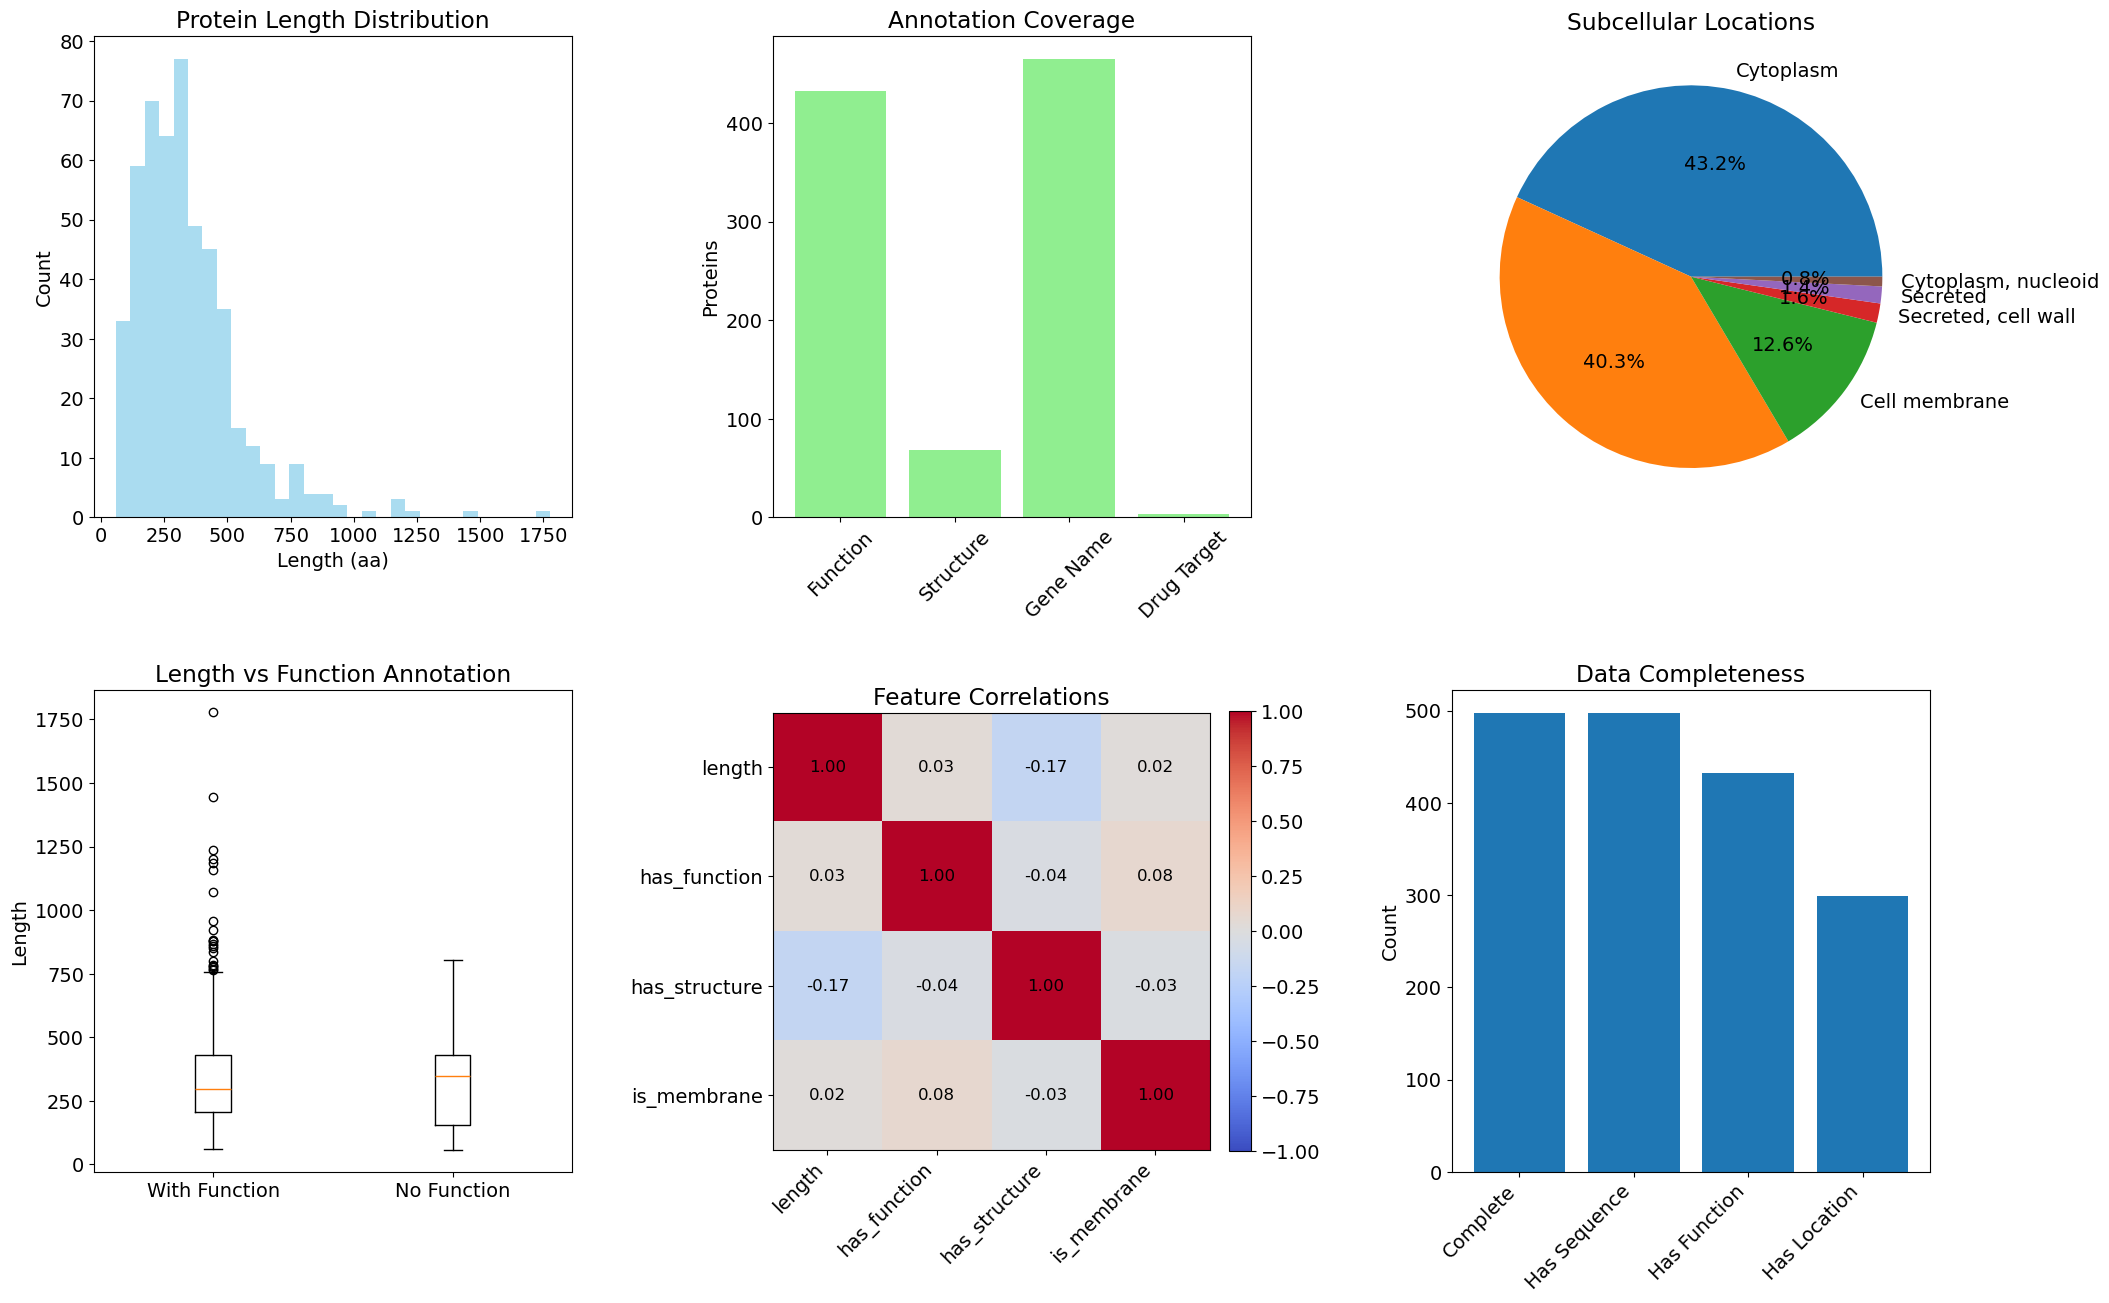

19:29:05  INFO      Physicochemical features added. Stable proteins: 383
19:29:05  INFO      Running ClustalOmega on 497 sequences...
19:29:06  WARNING   clustalo not found on PATH — returning 0.5 for all conservation scores.
19:29:06  INFO      Known positives: 3  |  Unlabelled: 494
19:29:06  INFO      Using PU learning (ElkanotoPuClassifier).
19:29:06  WARNING   PU model CV failed (
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\surat\miniconda3\envs\research\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\surat\AppData\Local\Temp\ipykernel_36064\1460722587.py", line 37, in fit

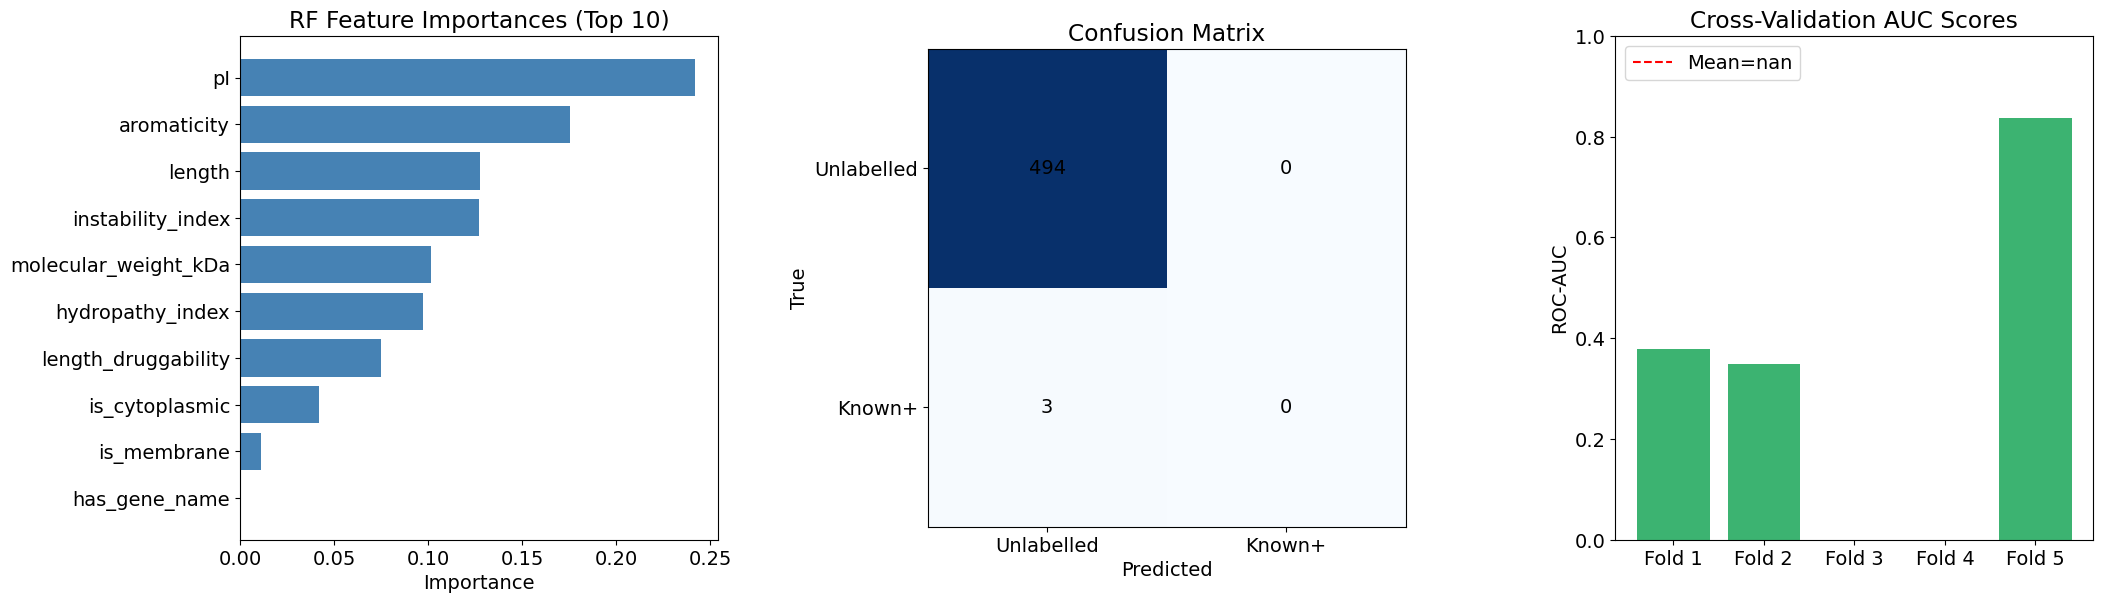

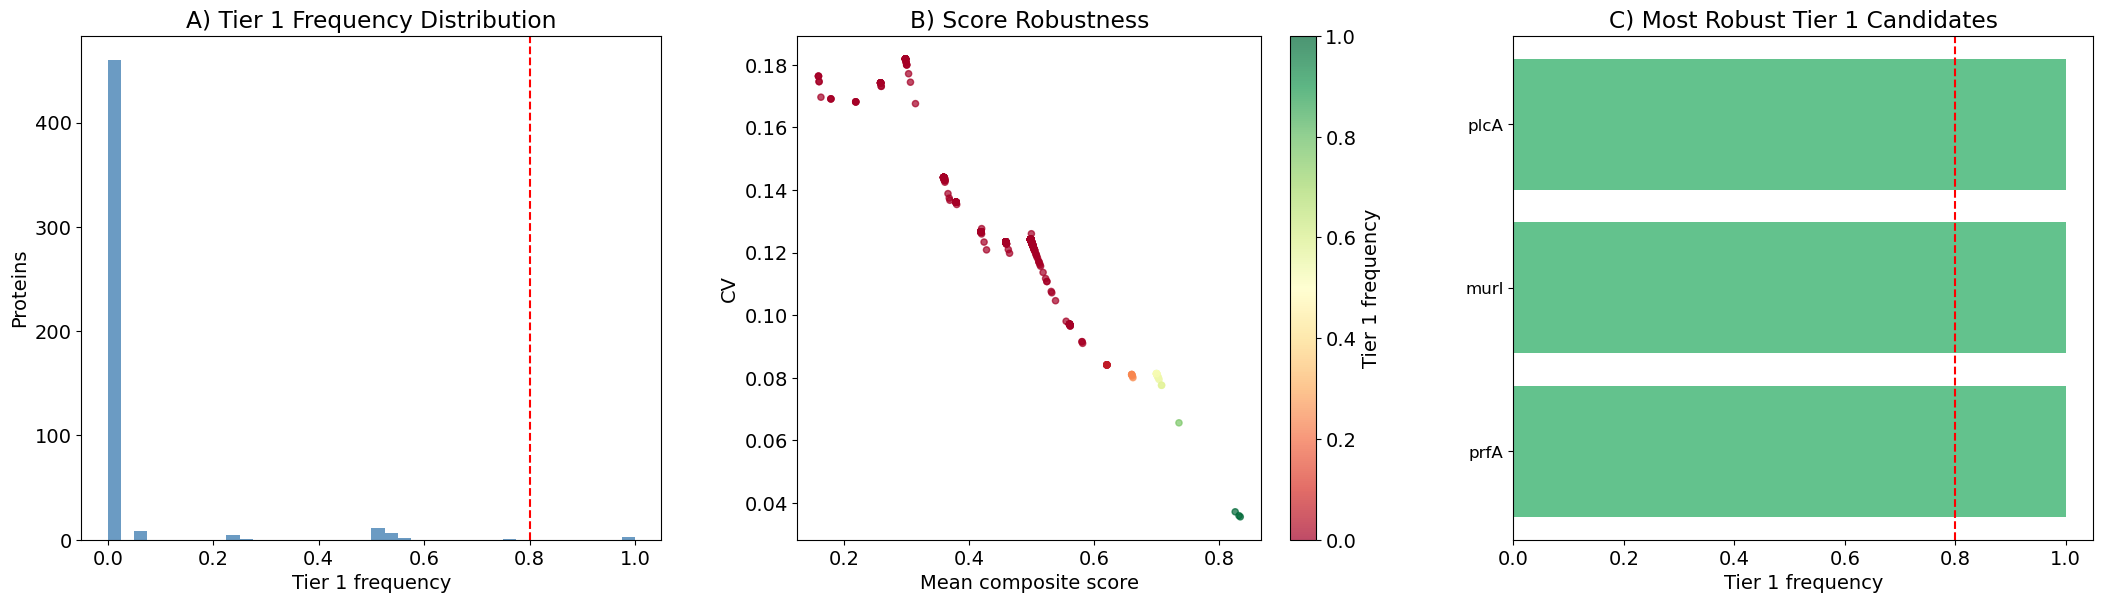

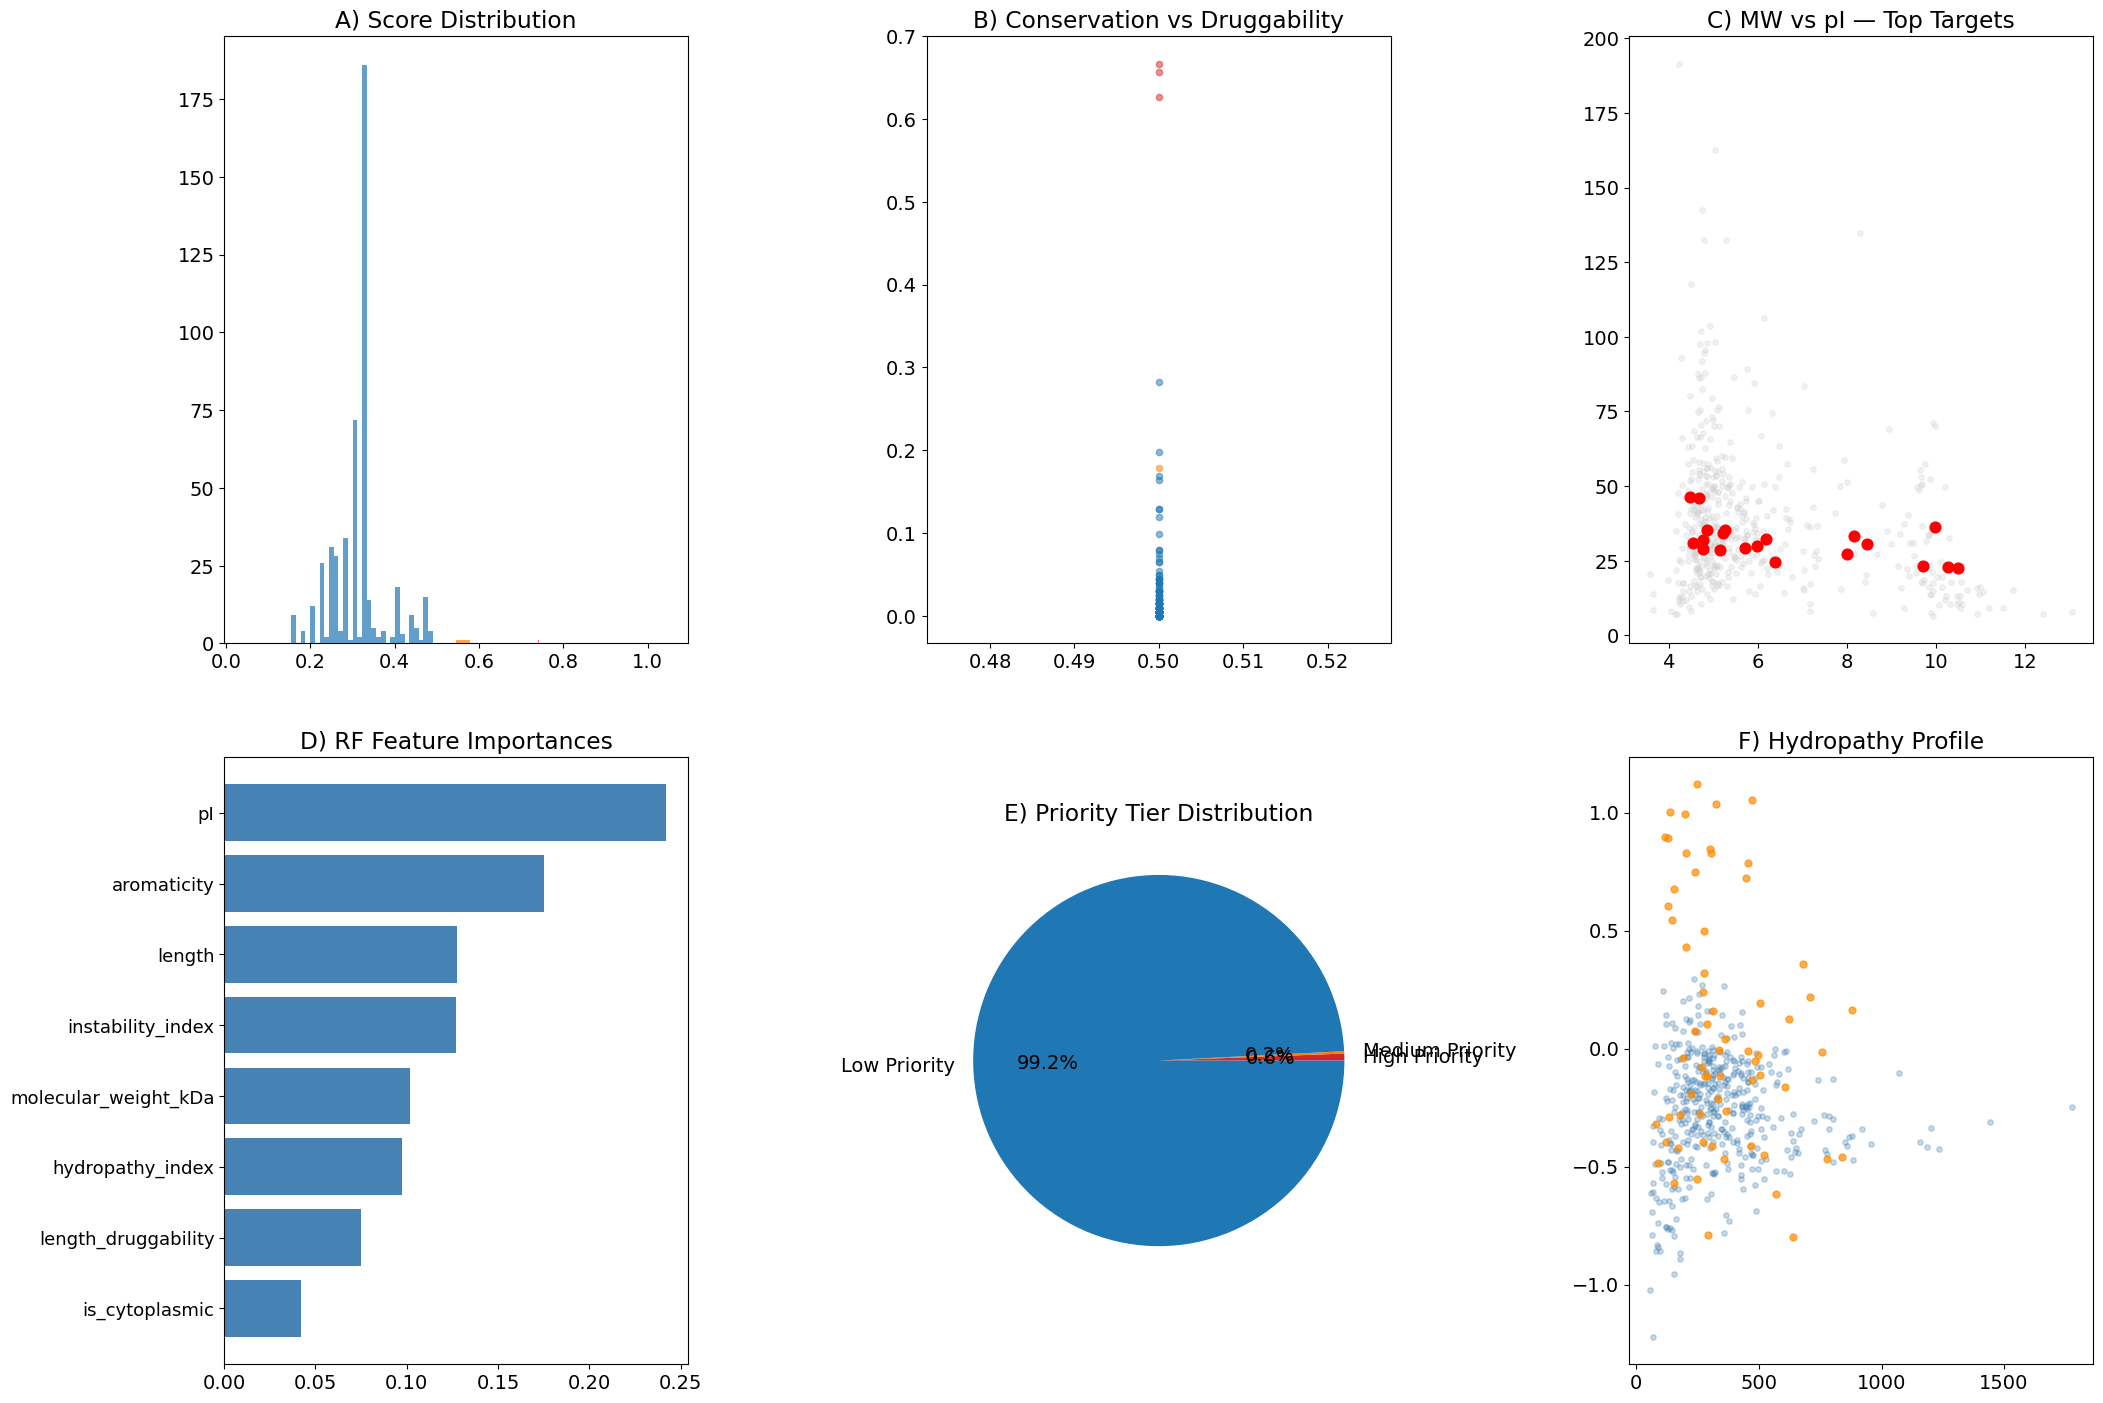

19:30:04  INFO      Pipeline Complete. Data saved to 'listeria_final_results.csv'


In [40]:
# ── Execute Pipeline ─────────────────────────────────────────────────────────

# 1. Fetch & Process
raw_data       = fetch_listeria_proteome()
proteins_df    = process_uniprot_data(raw_data)
proteins_clean = clean_data(proteins_df)
proteins_clean = assign_length_druggability(proteins_clean)
proteins_clean = add_feature_flags(proteins_clean)

# 2. Exploratory Data Analysis
run_eda(proteins_clean)

# 3. Features & Alignment
proteins_clean = add_physicochemical_features(proteins_clean)
proteins_clean = add_conservation_scores(proteins_clean)

# 4. Machine Learning
proteins_clean, model, cv_scores, importances, y_pred_cv, y = build_and_evaluate_model(proteins_clean)
plot_model_evaluation(y, y_pred_cv, cv_scores, importances)

# 5. Sensitivity & Ranking
proteins_clean["composite_target_score"] = proteins_clean.apply(compute_target_score, axis=1)
proteins_clean["priority_tier"]          = proteins_clean["composite_target_score"].apply(assign_tier)

proteins_clean = run_monte_carlo_sensitivity(proteins_clean)
plot_monte_carlo(proteins_clean)

proteins_final, tier_counts, top20 = rank_targets(proteins_clean)
plot_results(proteins_final, importances, top20)

# 6. Save File to Colab Environment
proteins_final.to_csv("listeria_final_results.csv", index=False)
log.info("Pipeline Complete. Data saved to 'listeria_final_results.csv'")